In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

In [6]:
loc = 'C:/Users/LAPTOP/Downloads/drug200.csv'
drug_tree = pd.read_csv(loc)
drug_tree.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [7]:
m = drug_tree.Class.unique()
m

AttributeError: 'DataFrame' object has no attribute 'Class'

In [19]:
drug_tree.info()
drug_tree.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [20]:
lab = LabelEncoder()
drug_tree['Sex'] = lab.fit_transform(drug_tree['Sex'])
drug_tree['BP'] = lab.fit_transform(drug_tree['BP'])
drug_tree['Cholesterol'] = lab.fit_transform(drug_tree['Cholesterol'])
drug_tree

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY
...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC
196,16,1,1,0,12.006,drugC
197,52,1,2,0,9.894,drugX
198,23,1,2,1,14.020,drugX


In [21]:
#drug_tree['Drug'] = drug_tree['Drug'].astype('category').cat.codes

In [31]:
my_map = {'DrugA':0, 'DrugB':1, 'DrugC':2, 'DrugX':3, 'DrugY':4}
#unmap = {0:'DrugA', 1:'DrugB', 2:'DrugC', 3:'DrugX', 4:'DrugY'}
#drug_tree['Drug'] = drug_tree['Drug'].map(unmap)
drug_tree['Drug val'] = drug_tree['Drug'].map(my_map)
drug_tree

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Drug val
0,23,0,0,0,25.355,DrugY,4
1,47,1,1,0,13.093,DrugC,2
2,47,1,1,0,10.114,DrugC,2
3,28,0,2,0,7.798,DrugX,3
4,61,0,1,0,18.043,DrugY,4
...,...,...,...,...,...,...,...
195,56,0,1,0,11.567,DrugC,2
196,16,1,1,0,12.006,DrugC,2
197,52,1,2,0,9.894,DrugX,3
198,23,1,2,1,14.020,DrugX,3


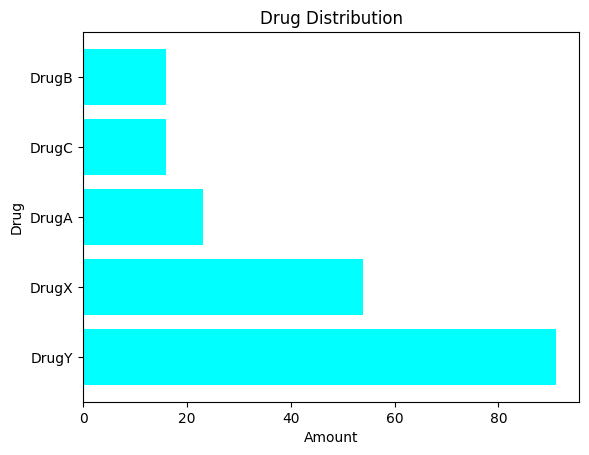

In [97]:
#drug_tree.drop(columns='Drug').corr()['Drug val']
val_counts = drug_tree['Drug'].value_counts()
plt.barh(val_counts.index, val_counts.values, color='cyan')
plt.ylabel('Drug')
plt.xlabel('Amount')
plt.title('Drug Distribution')
plt.show()

In [53]:
ind = drug_tree.drop(['Drug', 'Drug val'],axis=1)
dep = drug_tree['Drug']

In [94]:
train_ind, test_ind, train_dep, test_dep = train_test_split(ind, dep, test_size=.3, random_state=32)#, stratify=dep)

In [95]:
shears = DecisionTreeClassifier(criterion='entropy', max_depth=4)
shears.fit(train_ind, train_dep)
pred_dep = shears.predict(test_ind)
acc = metrics.accuracy_score
print(f'Accuracy: {np.round(100*acc(pred_dep, test_dep),2)}%')

Accuracy: 98.33%


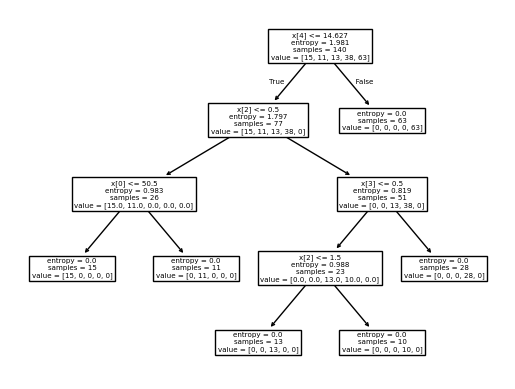

In [96]:
plot_tree(shears)
plt.show()